### 1. A nasty integral

Using Monte Carlo integration, check that

$$ \int_0^\infty x^3 \exp\left(-\frac{x^2}{2\sigma^2}\right) \,dx = 2\sigma^4 .$$

- Does the result converge with the number of samples? And how does the error go down?
- Do it many times. For a given $N$, how are the result distributed? We'll talk about model fitting at lenght later on, but for now try to fit it by hand with a parametrized model. (If N is large enough you should get something that looks *very* accurate! And if $N$ is small?)
- How does the distribution change if $N$ increases?

(Hint: think about sample mean and sample variance)

$$ I=\int_0^\infty x^3 e^{-x^2/(2\sigma^2)} \,dx .$$

$$ \phi_\sigma(x)=\frac{1}{\sigma\sqrt{2\pi}}e^{-x^2/(2\sigma^2)} .$$


$$ e^{-x^2/(2\sigma^2)}=\sigma\sqrt{2\pi},\phi_\sigma(x), .$$



$$ I=\sigma\sqrt{2\pi}\int_0^\infty x^3\phi_\sigma(x),dx .$$

$$ I=\sigma\sqrt{2\pi},\mathbb E[X^3,\mathbf 1_{X\ge 0}],\quad X\sim N(0,\sigma^2) .$$

$$ q(x)=2\phi_\sigma(x)\ \ (x\ge0) .$$

$$ I=\sigma\sqrt{\frac{\pi}{2}},\mathbb E_q[X^3]. .$$

$$ |\hat I_N^{(1)} - I_{\mathrm{true}}|,\dots,|\hat I_N^{(200)} - I_{\mathrm{true}}|. .$$



[0.30471708 1.03998411 0.7504512  0.94056472 1.95103519]


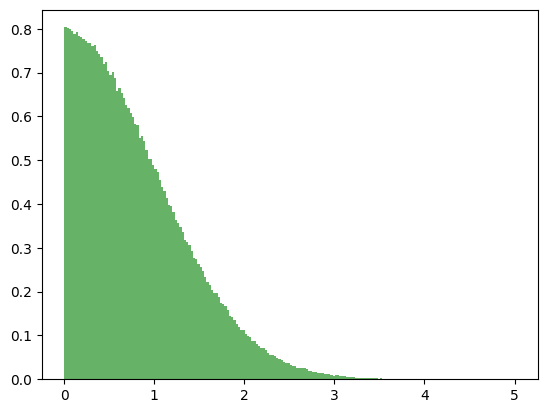

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

mu = 0.0
sigma = 1.0
n = 1000000


def fun(x, sigma):
    return np.power(x,3)*sigma*np.sqrt(2*np.pi)

rng = np.random.default_rng(42)
x = np.abs(rng.normal(0.0, sigma, size=n))
print(x[:5])

plt.hist(x, bins=int(np.sqrt(n)/5), density=True, alpha=0.6, color='g')
plt.show()


In [10]:
I = np.sum(fun(x, sigma))/n * (1/2)
print(I)
I_true = 2 * sigma**4
print(I_true)

2.0052680963203073
2.0


in pratica se campiono solo metà gaussiana, allora ho il prefattore 1/2 perchè effettivamente l'integrale di quella metà

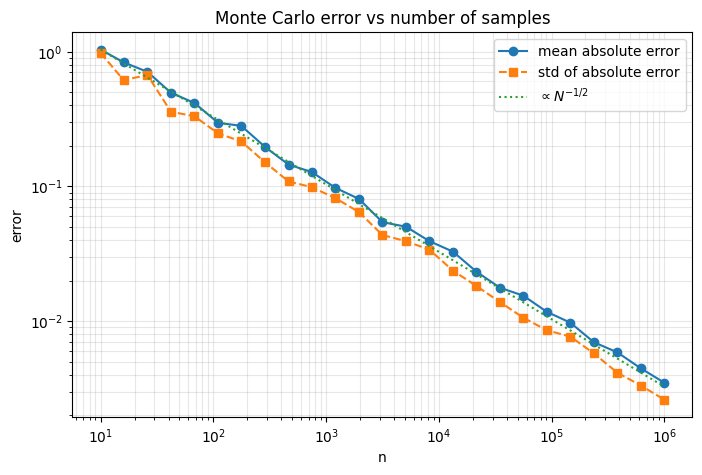

n =      10, mean |I - I_true| = 1.033949e+00
n =      16, mean |I - I_true| = 8.319519e-01
n =      26, mean |I - I_true| = 7.074871e-01
n =      42, mean |I - I_true| = 4.956821e-01
n =      68, mean |I - I_true| = 4.152728e-01
n =     110, mean |I - I_true| = 2.963087e-01
n =     177, mean |I - I_true| = 2.809831e-01
n =     287, mean |I - I_true| = 1.962092e-01
n =     464, mean |I - I_true| = 1.450717e-01
n =     749, mean |I - I_true| = 1.275948e-01
n =    1211, mean |I - I_true| = 9.743113e-02
n =    1957, mean |I - I_true| = 8.067921e-02
n =    3162, mean |I - I_true| = 5.426496e-02
n =    5108, mean |I - I_true| = 5.020515e-02
n =    8254, mean |I - I_true| = 3.921912e-02
n =   13335, mean |I - I_true| = 3.280009e-02
n =   21544, mean |I - I_true| = 2.329676e-02
n =   34807, mean |I - I_true| = 1.771851e-02
n =   56234, mean |I - I_true| = 1.544797e-02
n =   90851, mean |I - I_true| = 1.173157e-02
n =  146779, mean |I - I_true| = 9.745596e-03
n =  237137, mean |I - I_true| = 6

In [11]:
def estimate_integral(n, sigma, rng):
    x = np.abs(rng.normal(0.0, sigma, size=n))
    return 0.5 * np.mean(fun(x, sigma))


rng = np.random.default_rng(42)
n_values = np.unique(np.logspace(1, 6, 25, dtype=int))
mean_abs_errors = []
std_abs_errors = []
n_repeats = 200

for n_val in n_values:
    estimates = np.array([estimate_integral(n_val, sigma, rng) for _ in range(n_repeats)])
    abs_errors = np.abs(estimates - I_true)
    mean_abs_errors.append(abs_errors.mean())
    std_abs_errors.append(abs_errors.std())

mean_abs_errors = np.array(mean_abs_errors)
std_abs_errors = np.array(std_abs_errors)

plt.figure(figsize=(8, 5))
plt.loglog(n_values, mean_abs_errors, 'o-', label='mean absolute error')
plt.loglog(n_values, std_abs_errors, 's--', label='std of absolute error')
plt.loglog(n_values, mean_abs_errors[0] * np.sqrt(n_values[0] / n_values), ':', label=r'$\propto N^{-1/2}$')
plt.xlabel('n')
plt.ylabel('error')
plt.title('Monte Carlo error vs number of samples')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()

for n_val, err in zip(n_values, mean_abs_errors):
    print(f'n = {n_val:7d}, mean |I - I_true| = {err:.6e}')

sistemo un poco questi codici, commento, scrivo i significati e li inverto


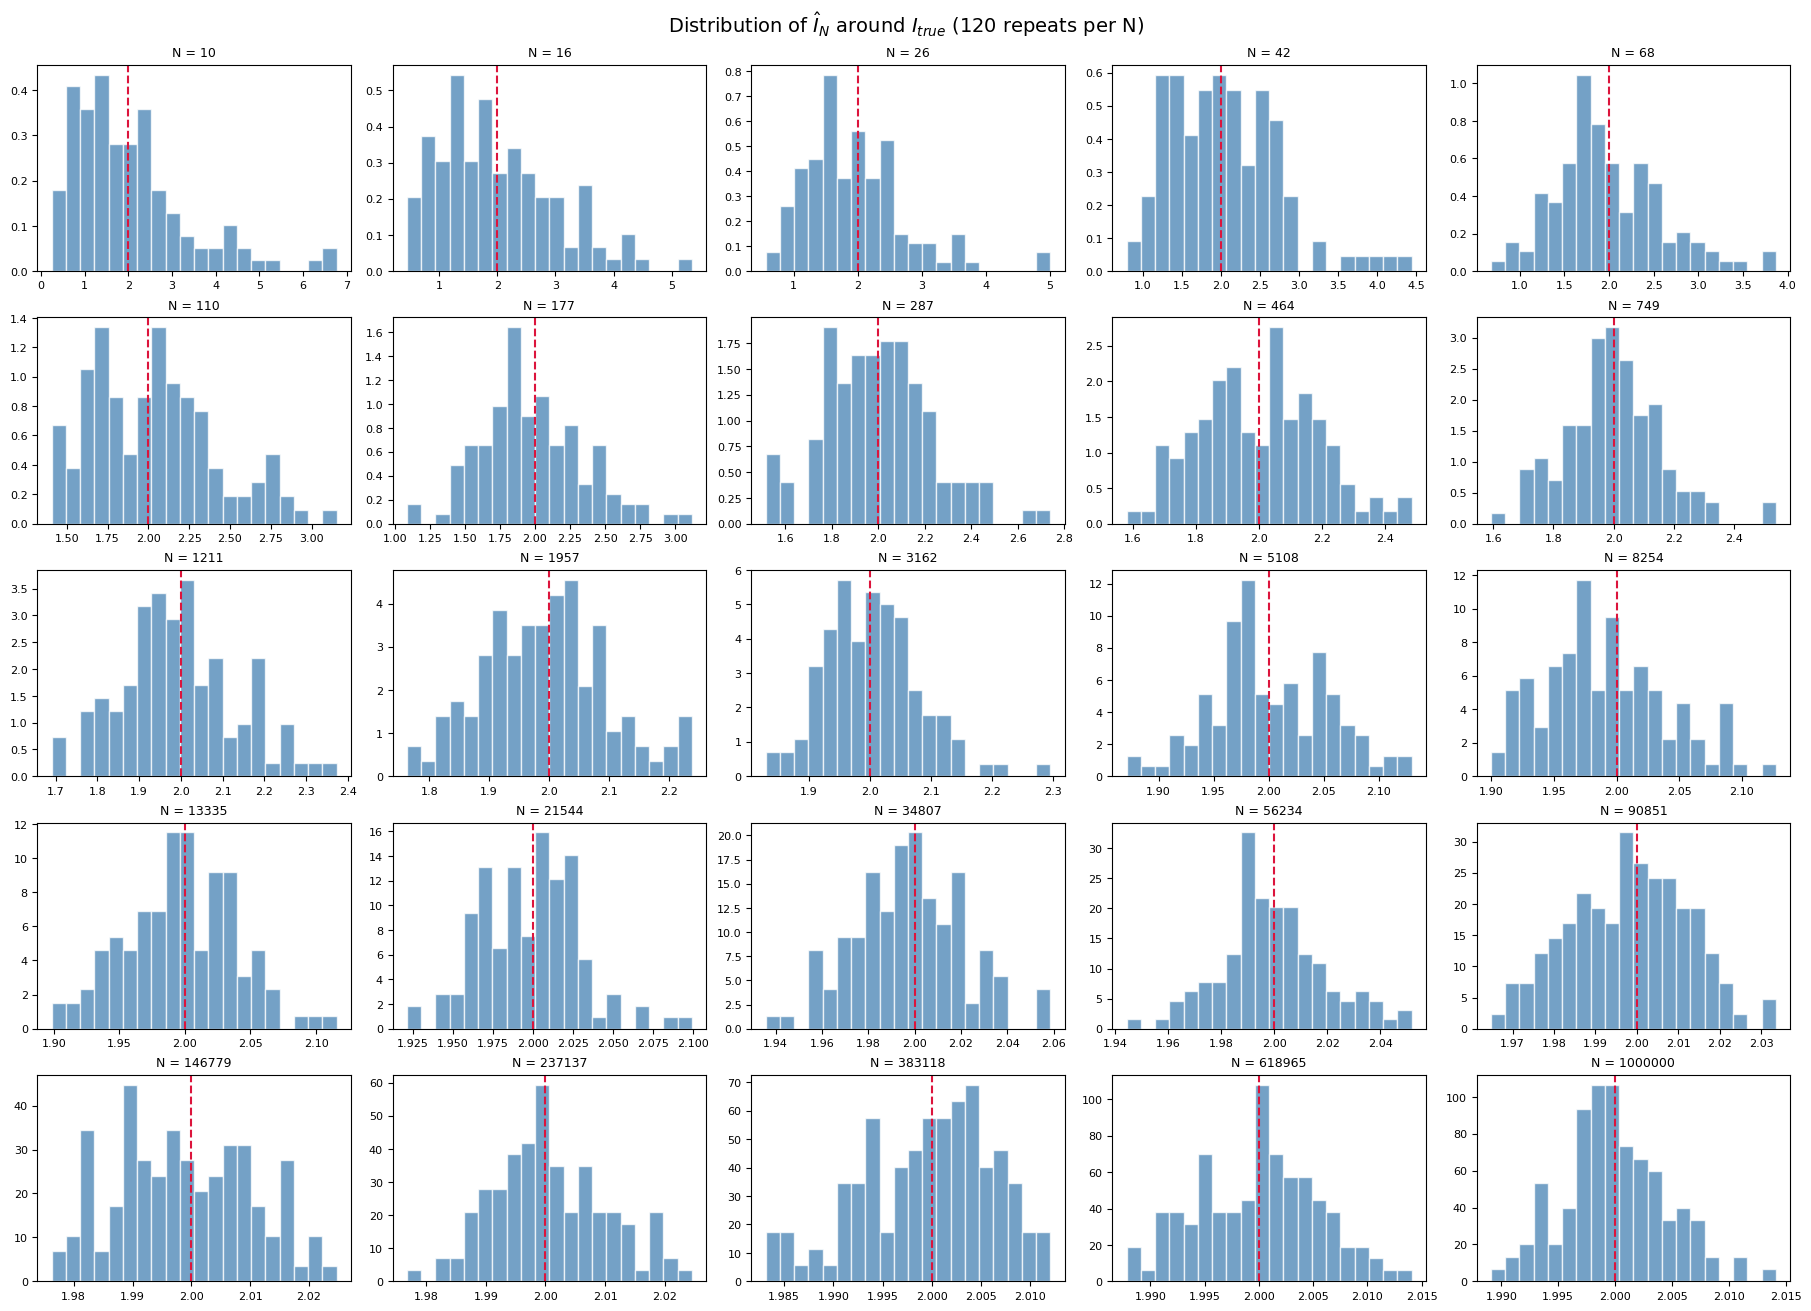

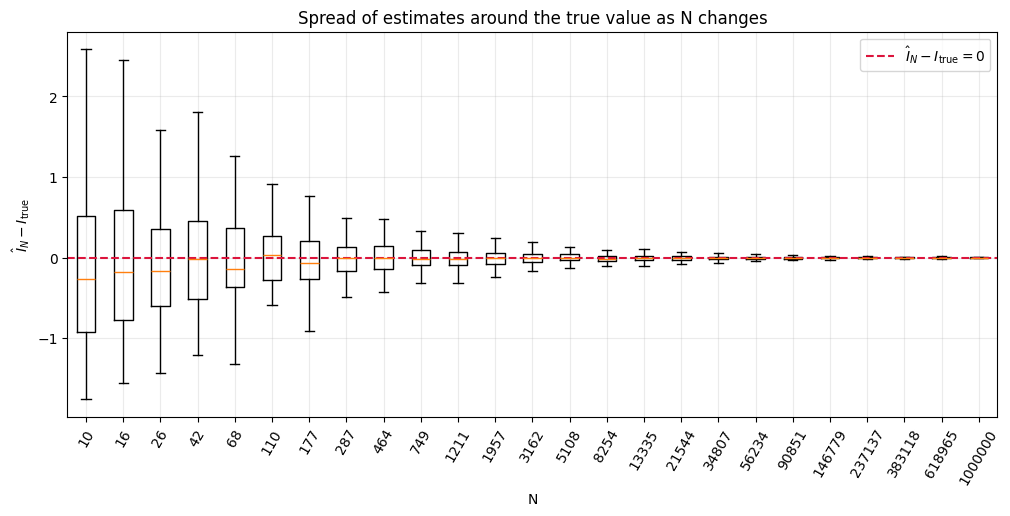

In [13]:
# Distribution of Monte Carlo estimates for each N in n_values
rng_dist = np.random.default_rng(123)
n_repeats_dist = 120

estimates_by_n = {}
for n_val in n_values:
    n_int = int(n_val)
    estimates_by_n[n_int] = np.array([estimate_integral(n_int, sigma, rng_dist) for _ in range(n_repeats_dist)])

n_cols = 5
n_rows = int(np.ceil(len(n_values) / n_cols))
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(3.6 * n_cols, 2.6 * n_rows),
    constrained_layout=True
)
axes = np.ravel(axes)

for ax, n_val in zip(axes, n_values):
    n_int = int(n_val)
    vals = estimates_by_n[n_int]
    ax.hist(vals, bins=20, density=True, alpha=0.75, color='steelblue', edgecolor='white')
    ax.axvline(I_true, color='crimson', linestyle='--', linewidth=1.5)
    ax.set_title(f'N = {n_int}', fontsize=9)
    ax.tick_params(labelsize=8)

for ax in axes[len(n_values):]:
    ax.axis('off')

fig.suptitle(
    f'Distribution of $\\hat{{I}}_N$ around $I_{{true}}$ ({n_repeats_dist} repeats per N)',
    fontsize=14
)
plt.show()

# Second view: centered errors for all N
centered_errors = [estimates_by_n[int(n_val)] - I_true for n_val in n_values]

plt.figure(figsize=(12, 5))
plt.boxplot(centered_errors, showfliers=False)
plt.axhline(0.0, color='crimson', linestyle='--', linewidth=1.5, label=r'$\hat{I}_N - I_{\mathrm{true}} = 0$')
plt.xticks(
    np.arange(1, len(n_values) + 1),
    [str(int(n_val)) for n_val in n_values],
    rotation=60
)
plt.xlabel('N')
plt.ylabel(r'$\hat{I}_N - I_{\mathrm{true}}$')
plt.title('Spread of estimates around the true value as N changes')
plt.grid(alpha=0.25)
plt.legend()
plt.show()